In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.dm as dm
import esc_fresnel.esc_optics as esc_optics
import esc_fresnel.iefc as iefc

dm_flat = utils.load_fits('../data/esc_fresnel_dm_flat.fits')


In [2]:
amp_dir = '/npool/nvme/kianmilani/esc-wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/npool/nvme/kianmilani/esc-wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe


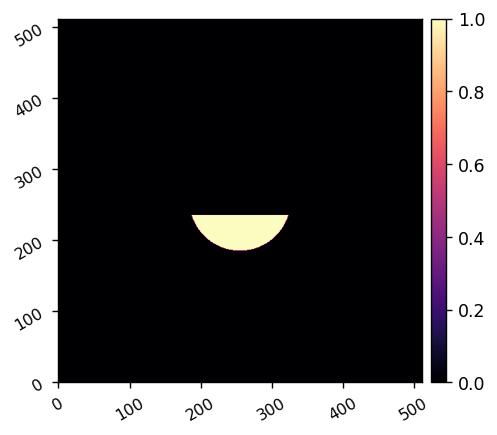

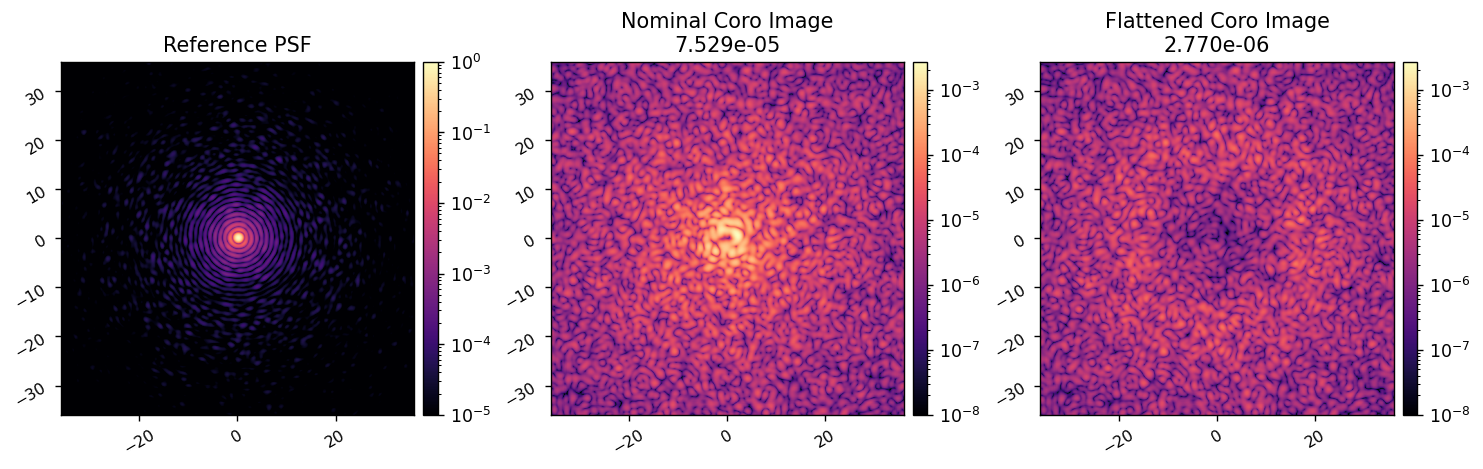

In [4]:
reload(esc)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 512

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
M.zero_dm()
coro_im_0 = M.snap()

M.reset_dm()
coro_im_flat = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.psf_pixelscale_lamD,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow1(coro_mask)

contrast_0 = utils.mean(coro_im_0, coro_mask)
contrast_flat = utils.mean(coro_im_flat, coro_mask)

imshow3(
    ref_psf/M.Imax_ref, coro_im_0, coro_im_flat,
    # ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask,
    f'Reference PSF',
    f'Nominal Coro Image\n{contrast_0:.3e}',
    f'Flattened Coro Image\n{contrast_flat:.3e}',
    lognorm=1,
    pxscl=M.psf_pixelscale_lamD,
    vmin1=1e-5, 
    vmin2=1e-8, vmax2=np.max(coro_im_0),
    vmin3=1e-8, vmax3=np.max(coro_im_0),
)

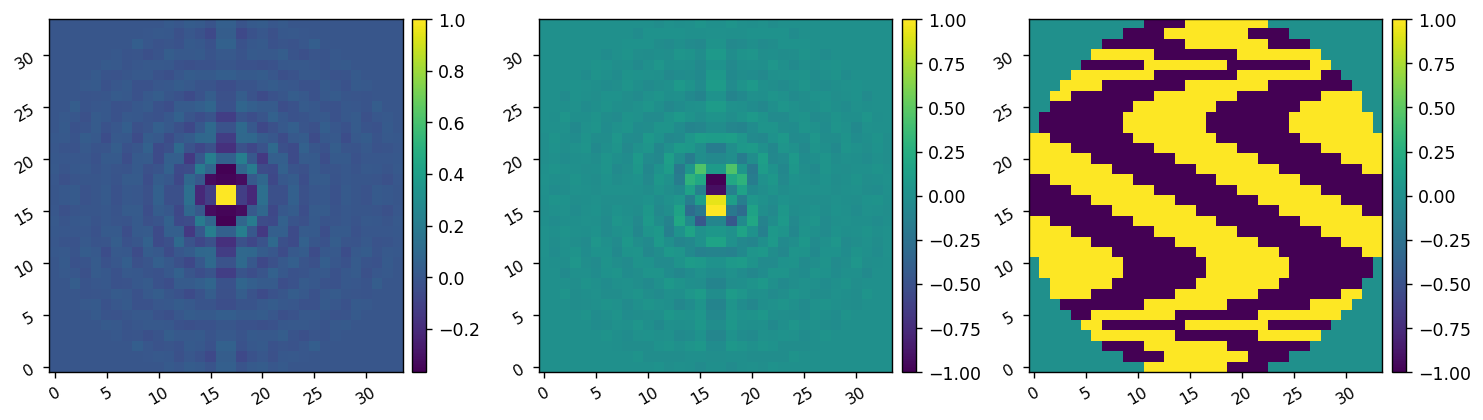

In [6]:
reload(utils)
fourier_probes = utils.create_fourier_probes(
    M.dm_mask, 
    M.npsf, 
    M.psf_pixelscale_lamD, 
    iwa-1, owa+2, 
    # iwa-1, 16, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
)

calib_modes = utils.create_hadamard_modes(M.dm_mask)

imshow3(fourier_probes[0], fourier_probes[1], calib_modes[8], cmap1='viridis', cmap2='viridis', cmap3='viridis')


Calibrating iEFC...
	Calibrated mode 1024/1024 in 2656.647s
Calibration complete.


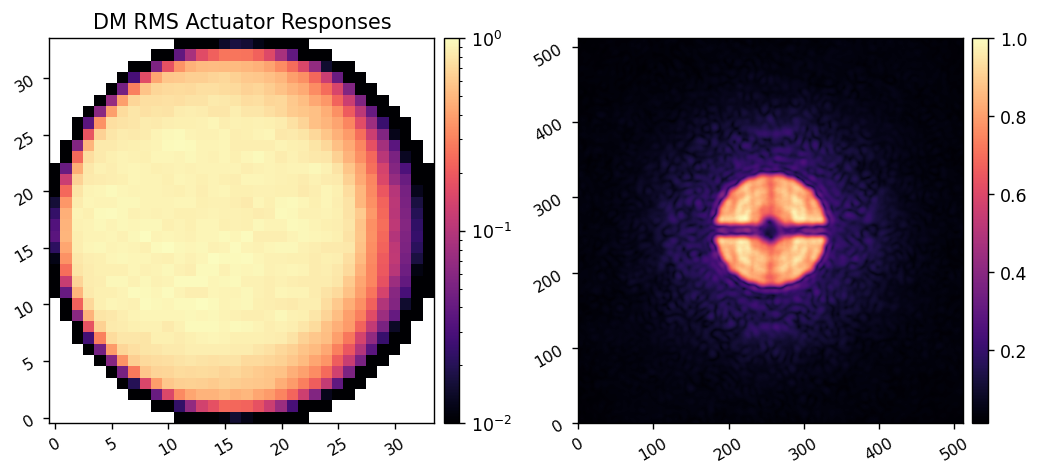

In [13]:
reload(iefc)
M.reset_dm()

probe_amp = 1e-9
calib_amp = 1e-9

response_matrix, response_cube = iefc.calibrate(
    M, 
    coro_mask, 
    probe_amp, fourier_probes, 
    calib_amp, calib_modes[:], 
    plot_responses=True,
    channel=3,
)

In [ ]:
calib_data = {
    'response_matrix':response_matrix,
    'response_cube':response_cube,
    'probe_mdoes':fourier_probes,
    'calib_modes':calib_modes,
}

# utils.save_pickle('../data/esc_fresnel_mono_iefc_calib.pkl', calib_data)
utils.save_pickle('./npool/nvme/kianmilani/esc-wfe-maps/esc_fresnel_mono_iefc_calib.pkl', calib_data)

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Saved data to:  /npool/nvme/kianmilani/esc-wfe-maps/esc_fresnel_mono_iefc_calib.pkl


In [25]:
reload(utils)
cm20 = utils.beta_reg(response_matrix, -2)
cm25 = utils.beta_reg(response_matrix, -2.5)
# cm30 = utils.beta_reg(response_matrix, -3)
# cm35 = utils.beta_reg(response_matrix, -3.5)
# cm40 = utils.beta_reg(response_matrix, -4)
cm45 = utils.beta_reg(response_matrix, -4.5)
cm50 = utils.beta_reg(response_matrix, -5)


In [20]:
M.reset_dm()
data = {
    'images':[coro_im_flat],
    'contrasts':[contrast_flat],
    'commands':[],
    'del_commands':[],
    'pixelscale':M.psf_pixelscale_lamD,
    'control_mask':coro_mask, 
    'probes':fourier_probes,
}

Running iEFC...
	Closed-loop iteration 28 / 30


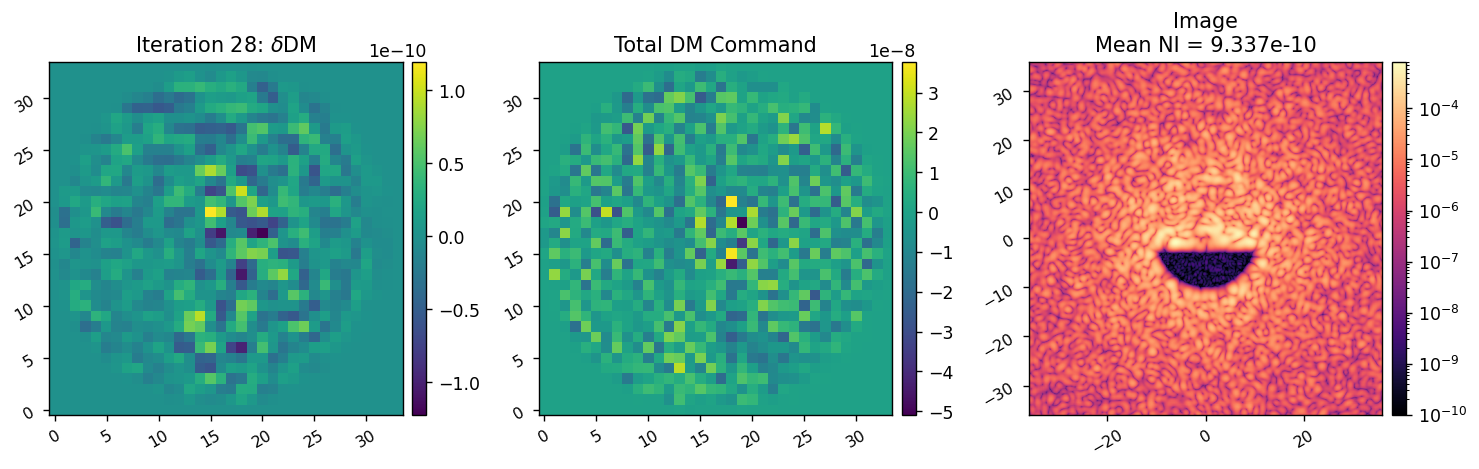

	Closed-loop iteration 29 / 30


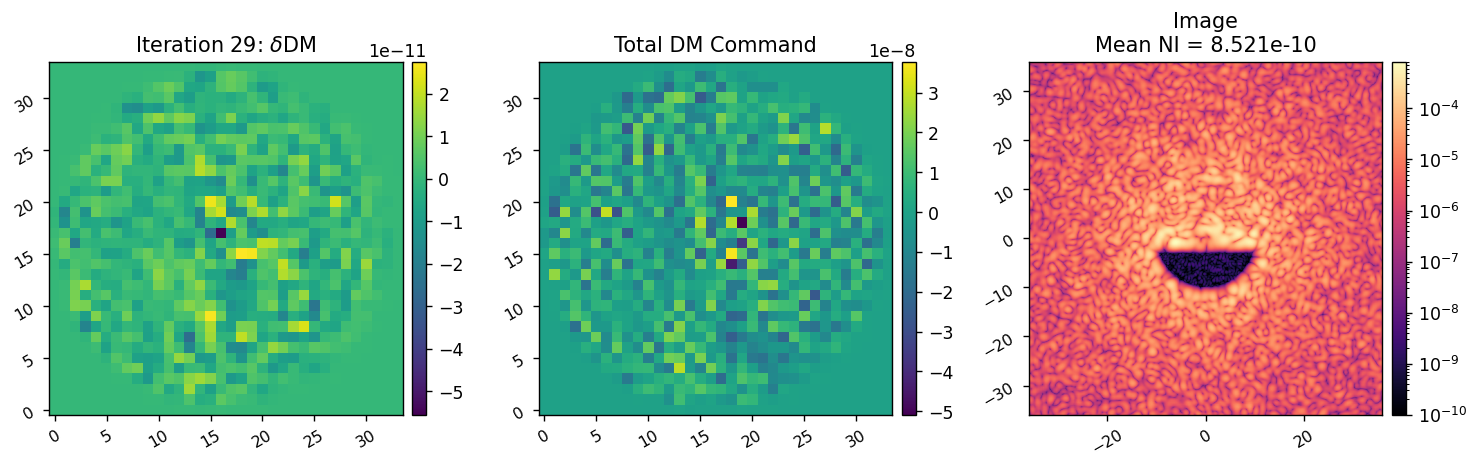

	Closed-loop iteration 30 / 30


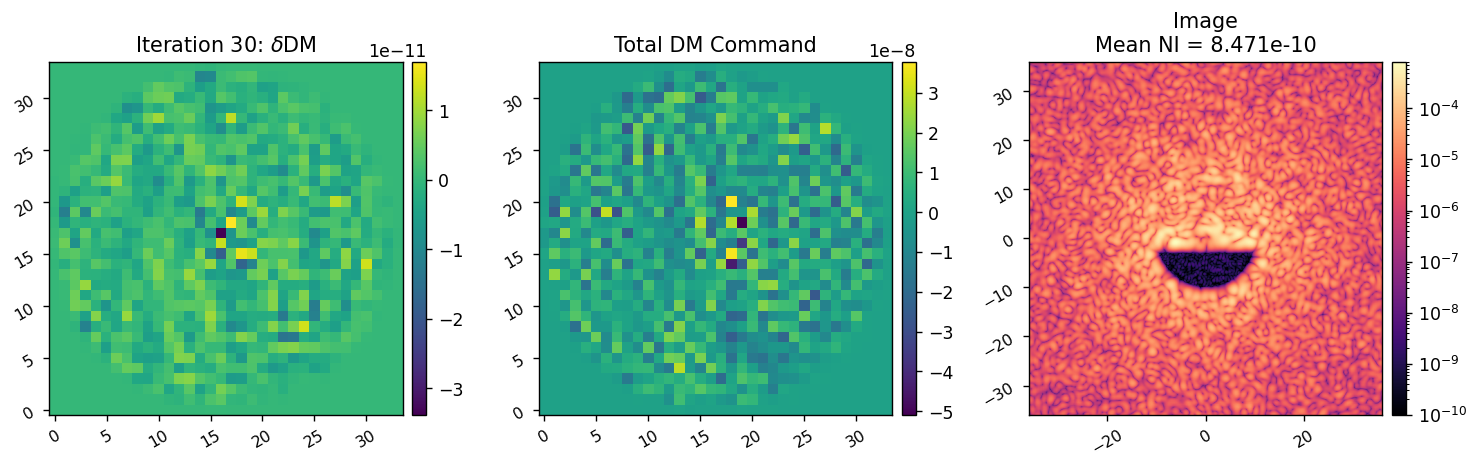

Closed loop for given control matrix completed in 7.085s.


In [31]:
reload(utils)
reload(iefc)

probe_amp = 2.5e-9
probe_amp = 1e-9
probe_amp = 0.25e-9

data = iefc.run(
    M,
    data,
    cm20,
    # cm25,
    # cm40,
    # cm45,
    # cm50,
    fourier_probes, 
    probe_amp, 
    calib_modes,
    coro_mask,
    channel=3,
    num_iterations=3,
    gain=1, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    plot_probes=False,
    vmin=1e-10,
)

In [32]:
utils.save_pickle('../data/esc_fresnel_iefc_data.pkl', data)

Saved data to:  ../data/esc_fresnel_iefc_data.pkl


In [34]:
utils.save_fits('../data/esc_fresnel_dm_dh_command.fits', data['commands'][-1])

Saved data to:  ../data/esc_fresnel_dm_dh_command.fits
